In [47]:
!pip install gdown  # Ensure gdown is installed

In [48]:
import gdown

# Replace FILE_ID with your actual file ID
file_id = "1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt"
output_file = "/content/Brain_Tumor_Datasets.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt
From (redirected): https://drive.google.com/uc?id=1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt&confirm=t&uuid=d48bdb68-e42d-42ff-a590-f1570bb995cc
To: /content/Brain_Tumor_Datasets.zip
100%|██████████| 32.9M/32.9M [00:00<00:00, 61.2MB/s]


'/content/Brain_Tumor_Datasets.zip'

In [49]:
import zipfile
z= zipfile.ZipFile('/content/Brain_Tumor_Datasets.zip')
z.extractall('/content/') # Extract to a specific directory

In [50]:
import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [51]:
# Set dataset directory paths
train_dir = "Brain_Tumor_Datasets/train"
test_dir = "Brain_Tumor_Datasets/test"

In [53]:
print(traindata.class_indices)

{'NO': 0, 'YES': 1}


(32, 2)
(32, 224, 224, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


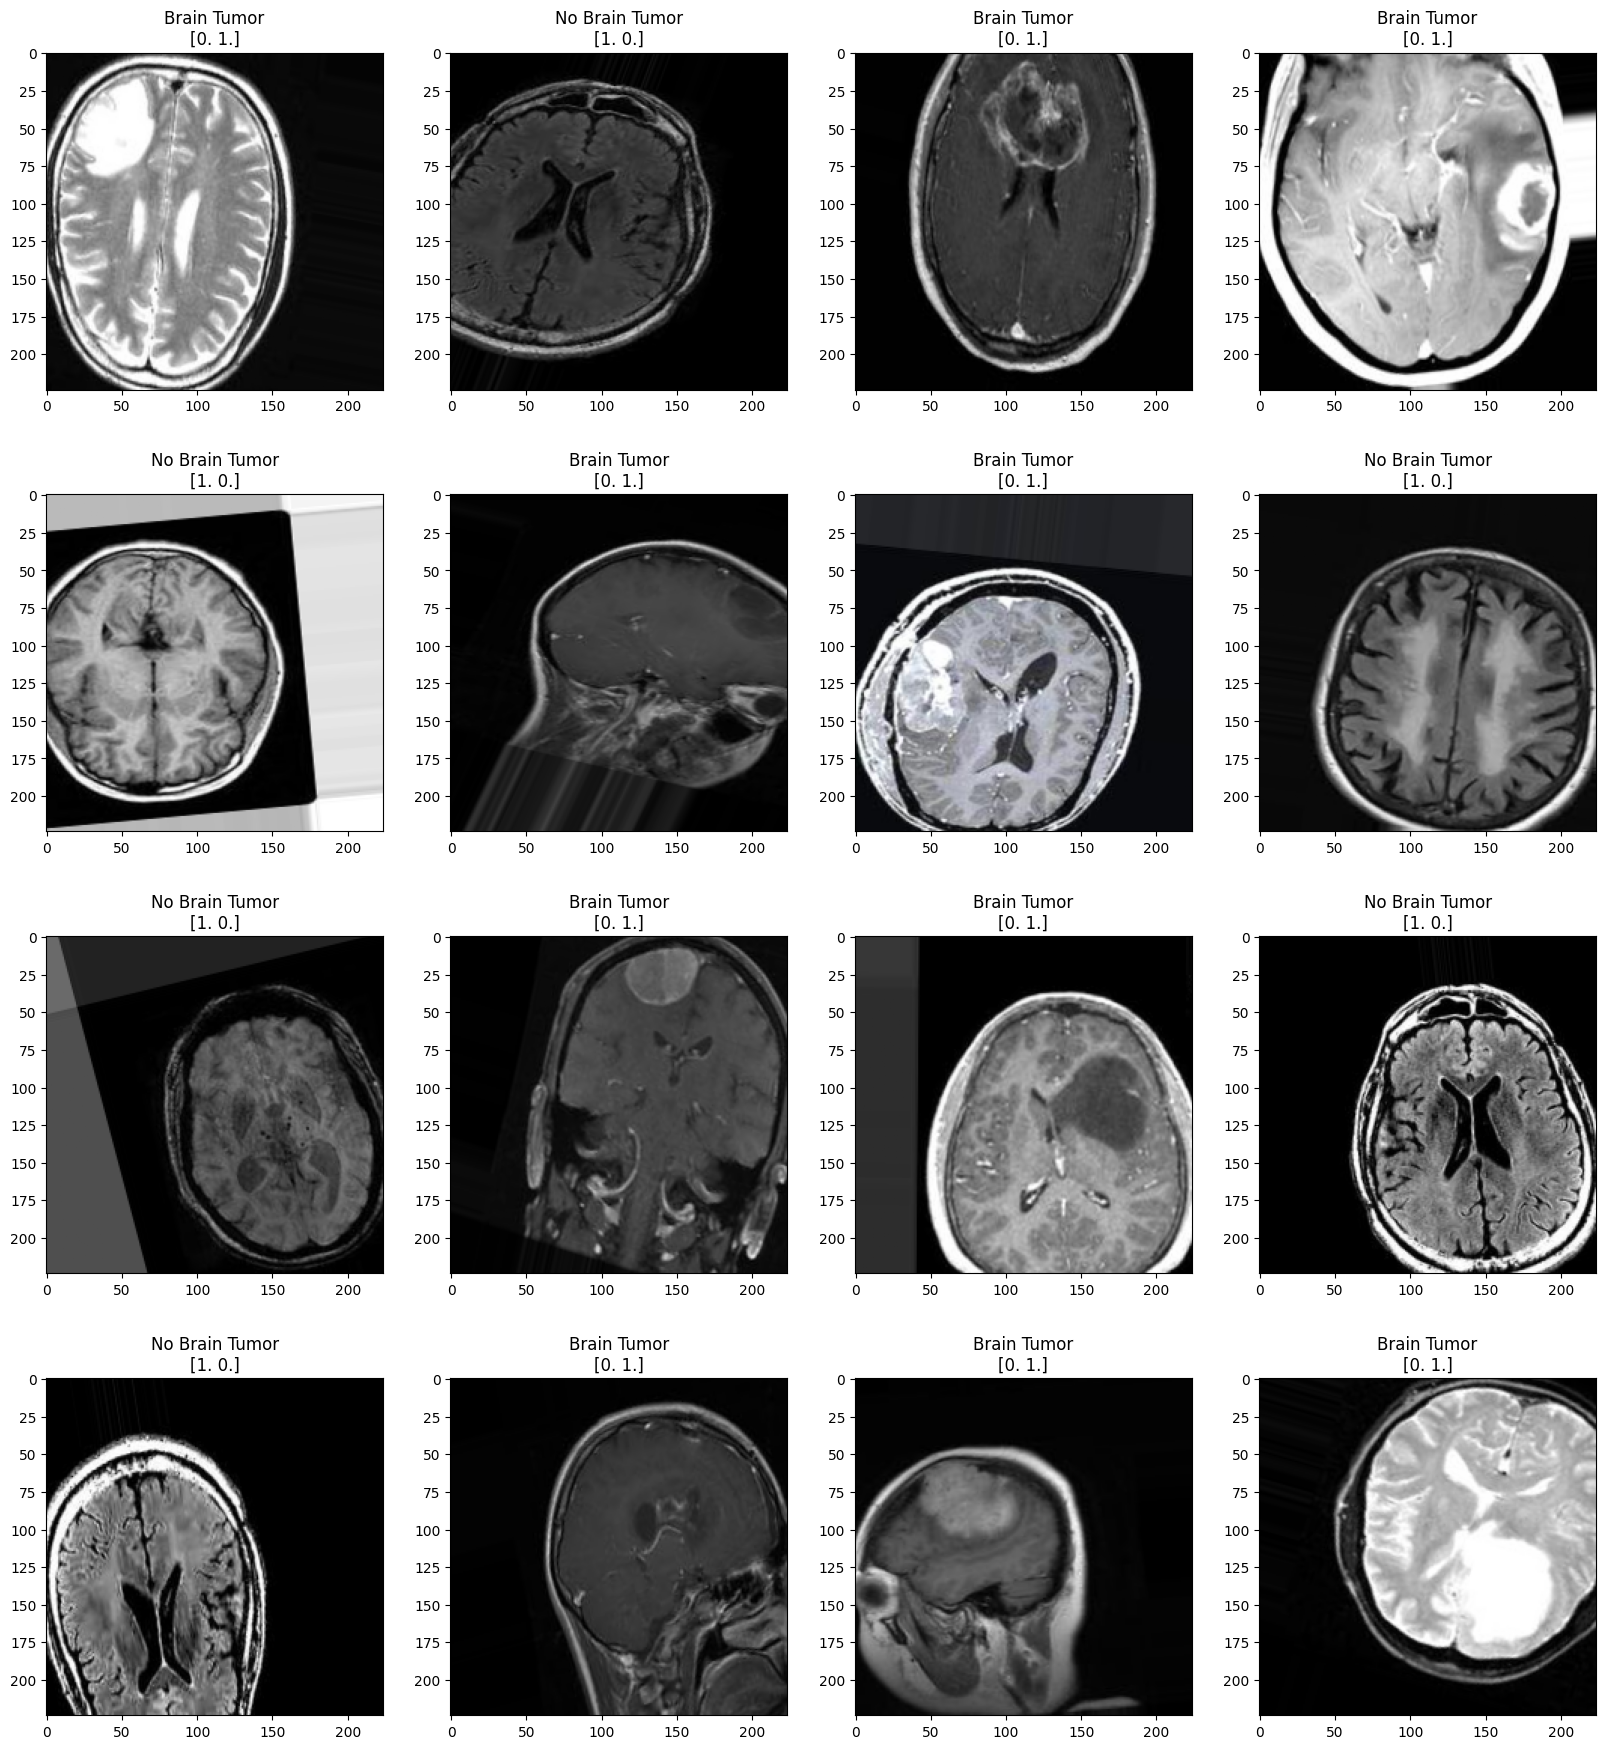

In [54]:
import numpy as np
import matplotlib.pyplot as plt

class_name = {0:'No Brain Tumor', 1:'Brain Tumor'}

trainiter = iter(traindata)
images,labels = next(trainiter)

print(labels.shape)
print(images.shape)
print(type(labels))
print(type(images))

fig,axes = plt.subplots(4,4,figsize=(20,22))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(images[i]) # Removed cmap='gray' as color_mode is 'rgb'
    index = np.argmax(labels[i])
    axes[i].set_title(f'{class_name[index]}\n{labels[i]}')

plt.show()

In [55]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
import tensorflow as tf

# Load the MobileNetV2 model with pre-trained weights from ImageNet, excluding the top classification layer
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers in the base MobileNetV2 model
for layer in mobilenet_base.layers:
    layer.trainable = False

# Build the new model on top of the MobileNetV2 base
model_mobilenet = Sequential()
model_mobilenet.add(mobilenet_base)
model_mobilenet.add(Flatten())
model_mobilenet.add(Dense(1024, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(256, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(128, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(2, activation='softmax')) # Output layer for 2 classes

# Compile the model
opt_mobilenet = Adam(learning_rate=0.0001)
model_mobilenet.compile(loss='categorical_crossentropy', optimizer=opt_mobilenet, metrics=['accuracy'])

model_mobilenet.summary()

# Define ModelCheckpoint and LearningRateScheduler callbacks
modelcheckpoint = ModelCheckpoint('model.keras',
                                  monitor = 'val_accuracy',
                                  save_best_only = True,
                                  mode = 'max',
                                  verbose = 1)

def scheduler(epoch, lr):
    return 0.0001 * (0.5 ** (epoch // 10))

lr_scheduler = LearningRateScheduler(scheduler)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │    64,226,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,785,474 (254.77 MB)

 Trainable params: 64,524,674 (246.14 MB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [57]:
# Train the MobileNetV2 model
history_mobilenet = model_mobilenet.fit(
    traindata,
    epochs=10,  # You can adjust the number of epochs
    validation_data=valdata,
    callbacks=[modelcheckpoint, lr_scheduler]
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9586 - loss: 0.1125
Epoch 1: val_accuracy improved from 0.96289 to 0.97221, saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 568s 5s/step - accuracy: 0.9586 - loss: 0.1125 - val_accuracy: 0.9722 - val_loss: 0.0747 - learning_rate: 1.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9657 - loss: 0.0982
Epoch 2: val_accuracy improved from 0.97221 to 0.97332, saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 573s 5s/step - accuracy: 0.9657 - loss: 0.0982 - val_accuracy: 0.9733 - val_loss: 0.0715 - learning_rate: 1.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9681 - loss: 0.0886
Epoch 3: val_accuracy improved from 0.97332 to 0.97749, saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 555s 5s/step - accuracy: 0.9681 - loss: 0.0887 - val_accuracy: 0.9775 - val_loss: 0.0661 - learning_rate: 1.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - ac

In [58]:
# Initialize the ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255) # Only rescaling for test data

# Load the test dataset using flow_from_directory
testdata = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb',  # Ensure color_mode is 'rgb'
    class_mode='categorical', # For integer labels
    shuffle=False # Do not shuffle test data for consistent evaluation
)

# Evaluate the model on the test dataset
loss, accuracy = model_mobilenet.evaluate(testdata)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 193 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8688 - loss: 0.4006
Test Loss: 0.3491
Test Accuracy: 0.8912


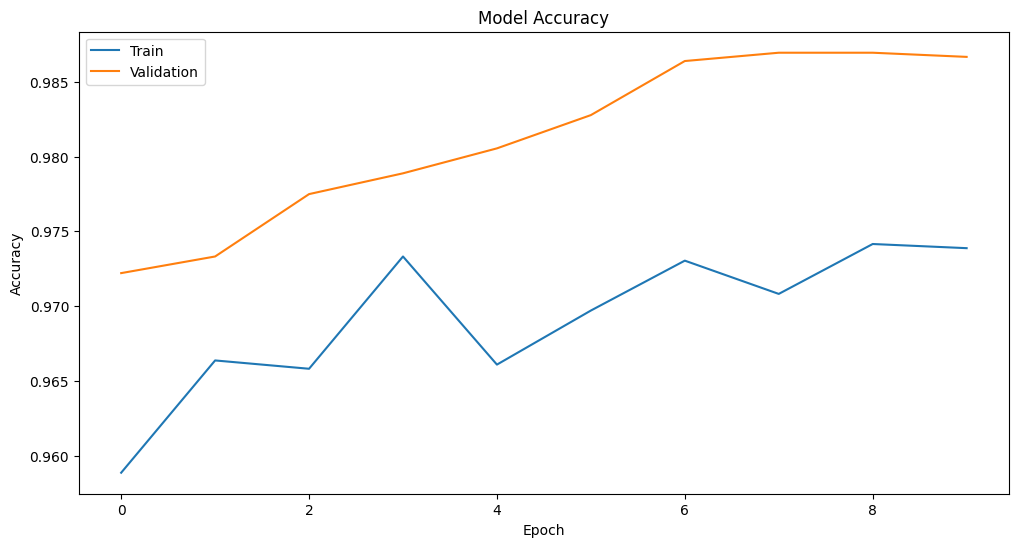

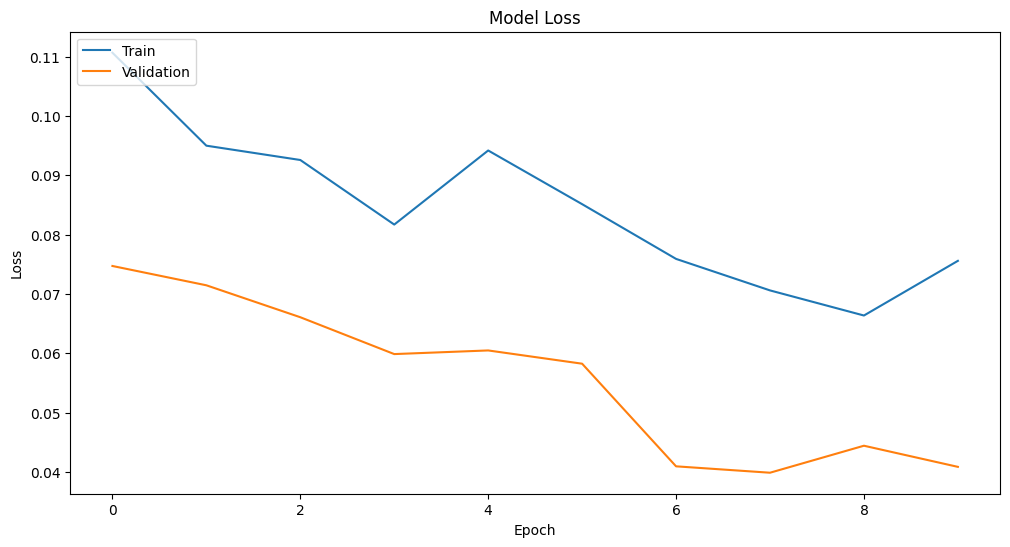

In [59]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [60]:
# Initialize the ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images to [0, 1]
    validation_split=0.2,  # Set validation split
    rotation_range=20,  # Random rotation between 0 and 20 degrees
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    shear_range=0.2,  # Random shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # How to fill in new pixels after transformation
)

# Load training and validation datasets using flow_from_directory
traindata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb', # Change color_mode to 'rgb'
    class_mode='categorical',  # For integer labels
    shuffle=True
)

# Load training and validation datasets using flow_from_directory
valdata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb', # Change color_mode to 'rgb'
    class_mode='categorical',
    shuffle=True
)

Found 3598 images belonging to 2 classes.
Found 3598 images belonging to 2 classes.


In [61]:
print(traindata.class_indices)

{'NO': 0, 'YES': 1}


(32, 2)
(32, 224, 224, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


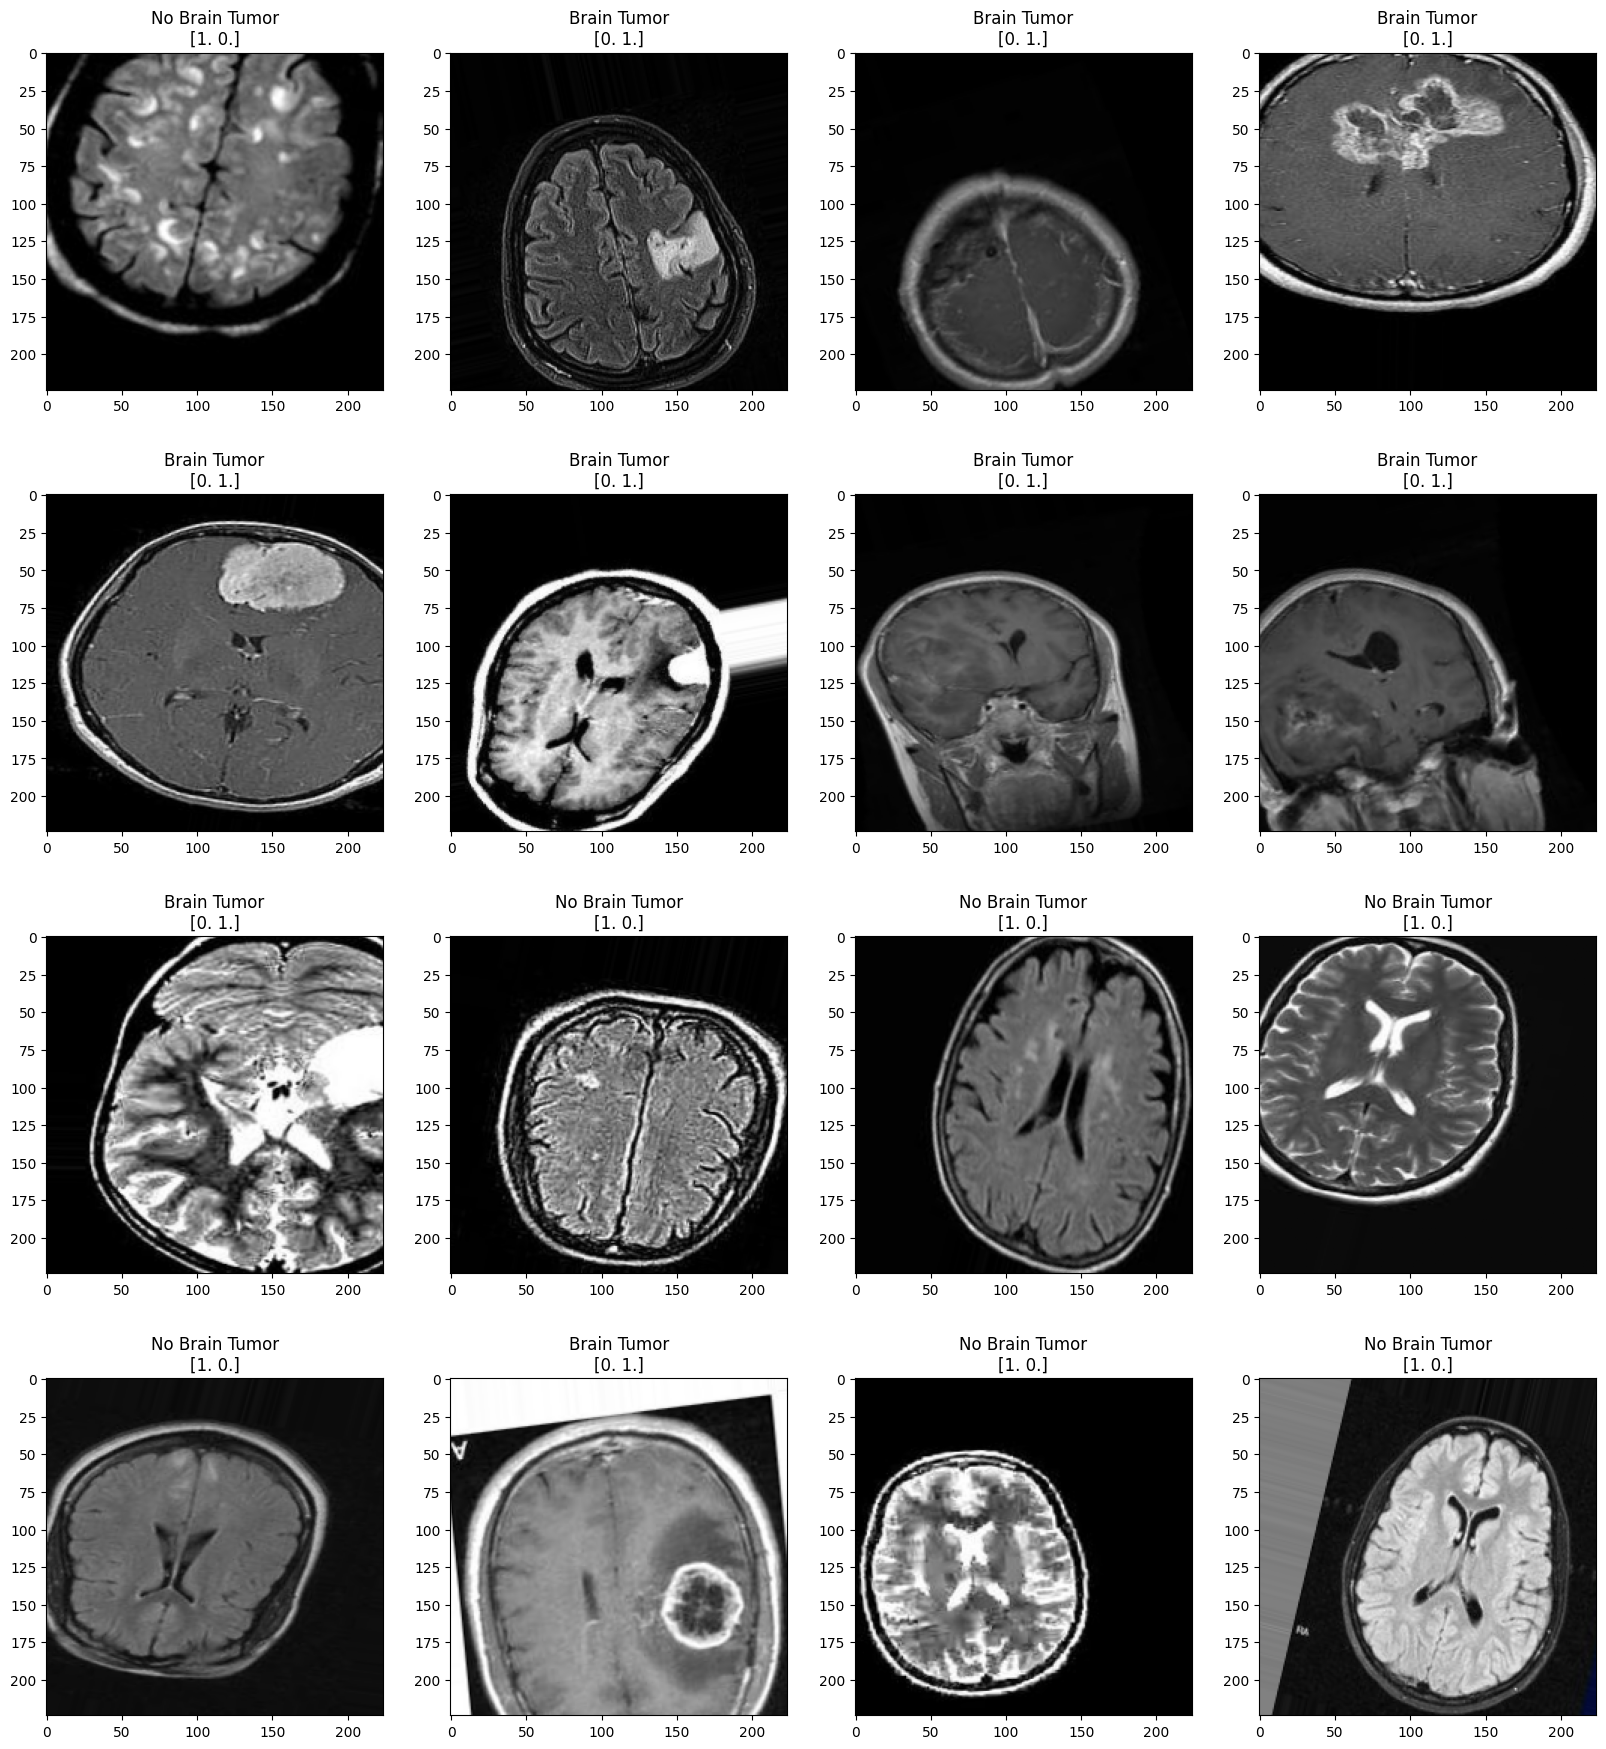

In [62]:
class_name = {0:'No Brain Tumor', 1:'Brain Tumor'}

trainiter = iter(traindata)
images,labels = next(trainiter)

print(labels.shape)
print(images.shape)
print(type(labels))
print(type(images))

fig,axes = plt.subplots(4,4,figsize=(20,22))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(images[i],cmap='gray')
    index = np.argmax(labels[i])
    axes[i].set_title(f'{class_name[index]}\n{labels[i]}')

plt.show()

In [63]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Load the MobileNetV2 model with pre-trained weights from ImageNet, excluding the top classification layer
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers in the base MobileNetV2 model
for layer in mobilenet_base.layers:
    layer.trainable = False

# Build the new model on top of the MobileNetV2 base
model_mobilenet = Sequential()
model_mobilenet.add(mobilenet_base)
model_mobilenet.add(Flatten())
model_mobilenet.add(Dense(1024, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(256, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(128, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(2, activation='softmax')) # Output layer for 2 classes

# Compile the model
opt_mobilenet = Adam(learning_rate=0.0001)
model_mobilenet.compile(loss='categorical_crossentropy', optimizer=opt_mobilenet, metrics=['accuracy'])

model_mobilenet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │    64,226,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,785,474 (254.77 MB)

 Trainable params: 64,524,674 (246.14 MB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [64]:
# Train the MobileNetV2 model
history_mobilenet = model_mobilenet.fit(
    traindata,
    steps_per_epoch=traindata.samples // traindata.batch_size,
    epochs=10,  # You can adjust the number of epochs
    validation_data=valdata,
    validation_steps=valdata.samples // valdata.batch_size,
    callbacks=[modelcheckpoint, lr_scheduler]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8088 - loss: 0.4754
Epoch 1: val_accuracy did not improve from 0.98694
112/112 ━━━━━━━━━━━━━━━━━━━━ 553s 5s/step - accuracy: 0.8093 - loss: 0.4743 - val_accuracy: 0.8870 - val_loss: 0.3374 - learning_rate: 1.0000e-04
Epoch 2/10
  1/112 ━━━━━━━━━━━━━━━━━━━━ 4:23 2s/step - accuracy: 0.9375 - loss: 0.1739

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.98694
112/112 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9375 - loss: 0.1739 - val_accuracy: 0.8848 - val_loss: 0.3263 - learning_rate: 1.0000e-04
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9281 - loss: 0.1840
Epoch 3: val_accuracy did not improve from 0.98694
112/112 ━━━━━━━━━━━━━━━━━━━━ 581s 5s/step - accuracy: 0.9281 - loss: 0.1840 - val_accuracy: 0.9364 - val_loss: 0.1836 - learning_rate: 1.0000e-04
Epoch 4/10
  1/112 ━━━━━━━━━━━━━━━━━━━━ 4:19 2s/step - accuracy: 0.9375 - loss: 0.1295
Epoch 4: val_accuracy did not improve from 0.98694
112/112 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9375 - loss: 0.1295 - val_accuracy: 0.9395 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9390 - loss: 0.1626
Epoch 5: val_accuracy did not improve from 0.98694
112/112 ━━━━━━━━━━━━━━━━━━━━ 533s 5s/step - accuracy: 0.9390 - loss: 0.1626 - val_accuracy: 0.9531 -

In [65]:
# Install gdown for downloading from Google Drive
!pip install gdown

In [66]:
import gdown
import zipfile
import os

# Replace FILE_ID with your actual file ID
file_id = "1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt"
output_file = "/content/Brain_Tumor_Datasets.zip"

# Download the file using gdown command-line tool
!gdown --id {file_id} -O {output_file}

# Extract the zip file
z = zipfile.ZipFile(output_file)
z.extractall('/content/')

# Verify extraction
print(os.listdir('/content/'))
print(os.listdir('/content/Brain_Tumor_Datasets/'))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt
From (redirected): https://drive.google.com/uc?id=1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt&confirm=t&uuid=5483daf1-2a39-44f2-b8b9-e856a308cac9
To: /content/Brain_Tumor_Datasets.zip
100% 32.9M/32.9M [00:00<00:00, 64.4MB/s]
['.config', 'model.keras', 'Brain_Tumor_Datasets.zip', 'Brain_Tumor_Datasets', 'sample_data']
['test', 'train']


In [70]:
# Set dataset directory paths
train_dir = "/content/Brain_Tumor_Datasets/train"
test_dir = "/content/Brain_Tumor_Datasets/test"

# Initialize the ImageDataGenerator for data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images to [0, 1]
    validation_split=0.2,  # Set validation split
    rotation_range=20,  # Random rotation between 0 and 20 degrees
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    shear_range=0.2,  # Random shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # How to fill in new pixels after transformation
)

# Load training and validation datasets using flow_from_directory
traindata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb',  # Change color_mode to 'rgb'
    class_mode='categorical',  # For integer labels
    shuffle=True
)

valdata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb',  # Change color_mode to 'rgb'
    class_mode='categorical',
    shuffle=True
)

print(traindata.class_indices)

Found 3598 images belonging to 2 classes.
Found 3598 images belonging to 2 classes.
{'NO': 0, 'YES': 1}


(32, 2)
(32, 224, 224, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


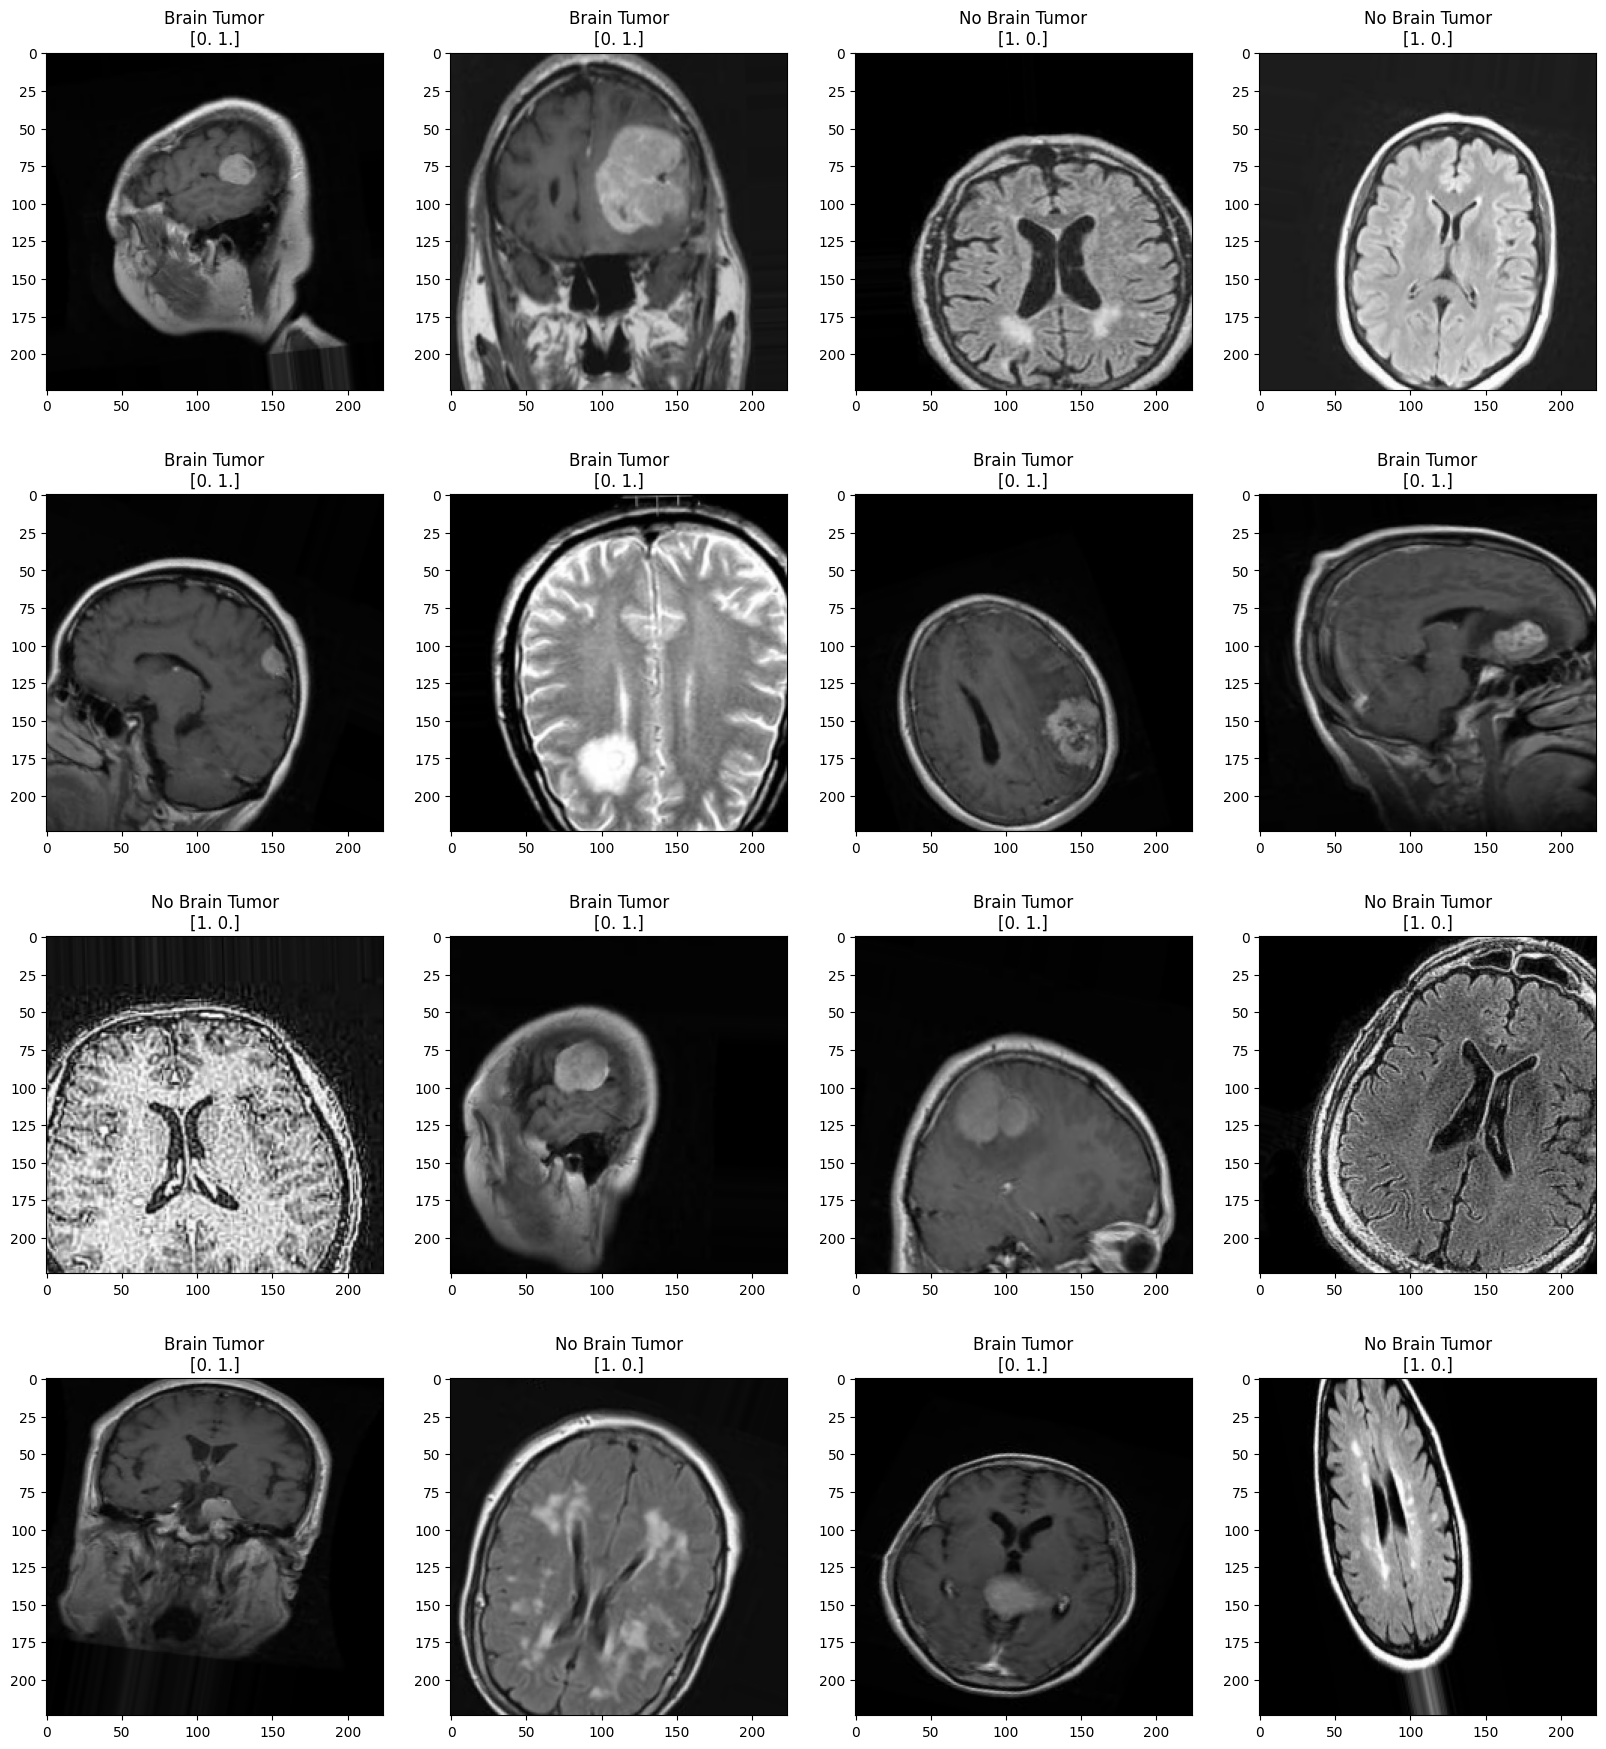

In [71]:
import numpy as np
import matplotlib.pyplot as plt

class_name = {0:'No Brain Tumor', 1:'Brain Tumor'}

trainiter = iter(traindata)
images,labels = next(trainiter)

print(labels.shape)
print(images.shape)
print(type(labels))
print(type(images))

fig,axes = plt.subplots(4,4,figsize=(20,22))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(images[i]) # Removed cmap='gray' as color_mode is 'rgb'
    index = np.argmax(labels[i])
    axes[i].set_title(f'{class_name[index]}\n{labels[i]}')

plt.show()

In [72]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
import tensorflow as tf

# Load the MobileNetV2 model with pre-trained weights from ImageNet, excluding the top classification layer
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers in the base MobileNetV2 model
for layer in mobilenet_base.layers:
    layer.trainable = False

# Build the new model on top of the MobileNetV2 base
model_mobilenet = Sequential()
model_mobilenet.add(mobilenet_base)
model_mobilenet.add(Flatten())
model_mobilenet.add(Dense(1024, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(256, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(128, activation='relu'))
model_mobilenet.add(BatchNormalization())
model_mobilenet.add(Dense(2, activation='softmax')) # Output layer for 2 classes

# Compile the model
opt_mobilenet = Adam(learning_rate=0.0001)
model_mobilenet.compile(loss='categorical_crossentropy', optimizer=opt_mobilenet, metrics=['accuracy'])

model_mobilenet.summary()

# Define ModelCheckpoint and LearningRateScheduler callbacks
modelcheckpoint = ModelCheckpoint('model.keras',
                                  monitor = 'val_accuracy',
                                  save_best_only = True,
                                  mode = 'max',
                                  verbose = 1)

def scheduler(epoch, lr):
    return 0.0001 * (0.5 ** (epoch // 10))

lr_scheduler = LearningRateScheduler(scheduler)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │    64,226,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,785,474 (254.77 MB)

 Trainable params: 64,524,674 (246.14 MB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [87]:
# Initialize the ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255) # Only rescaling for test data

# Load the test dataset using flow_from_directory
testdata = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb',  # Ensure color_mode is 'rgb'
    class_mode='categorical', # For integer labels
    shuffle=False # Do not shuffle test data for consistent evaluation
)

# Evaluate the model on the test dataset
loss, accuracy = model_mobilenet.evaluate(testdata)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 193 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8708 - loss: 0.3808
Test Loss: 0.3584
Test Accuracy: 0.8912


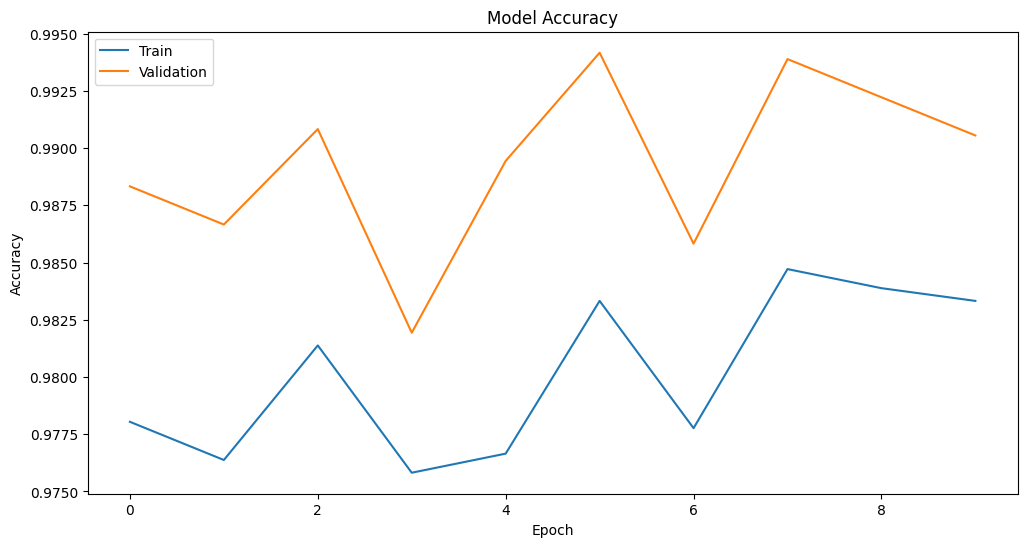

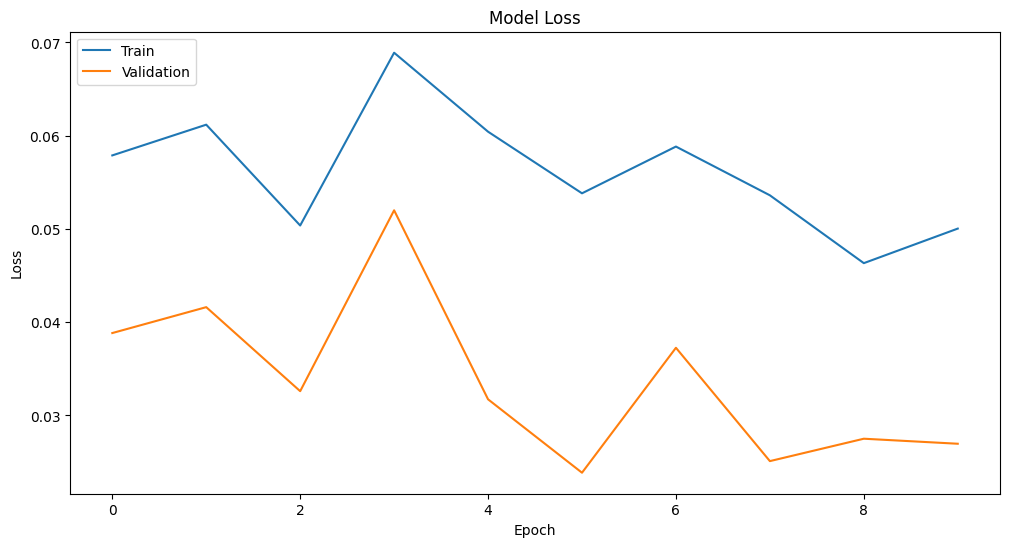

In [88]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [91]:
# Get a batch of images and labels from the test dataset
test_images, test_labels = next(testdata)

print(f"Shape of test images batch: {test_images.shape}")
print(f"Shape of test labels batch: {test_labels.shape}")

Shape of test images batch: (32, 224, 224, 3)
Shape of test labels batch: (32, 2)


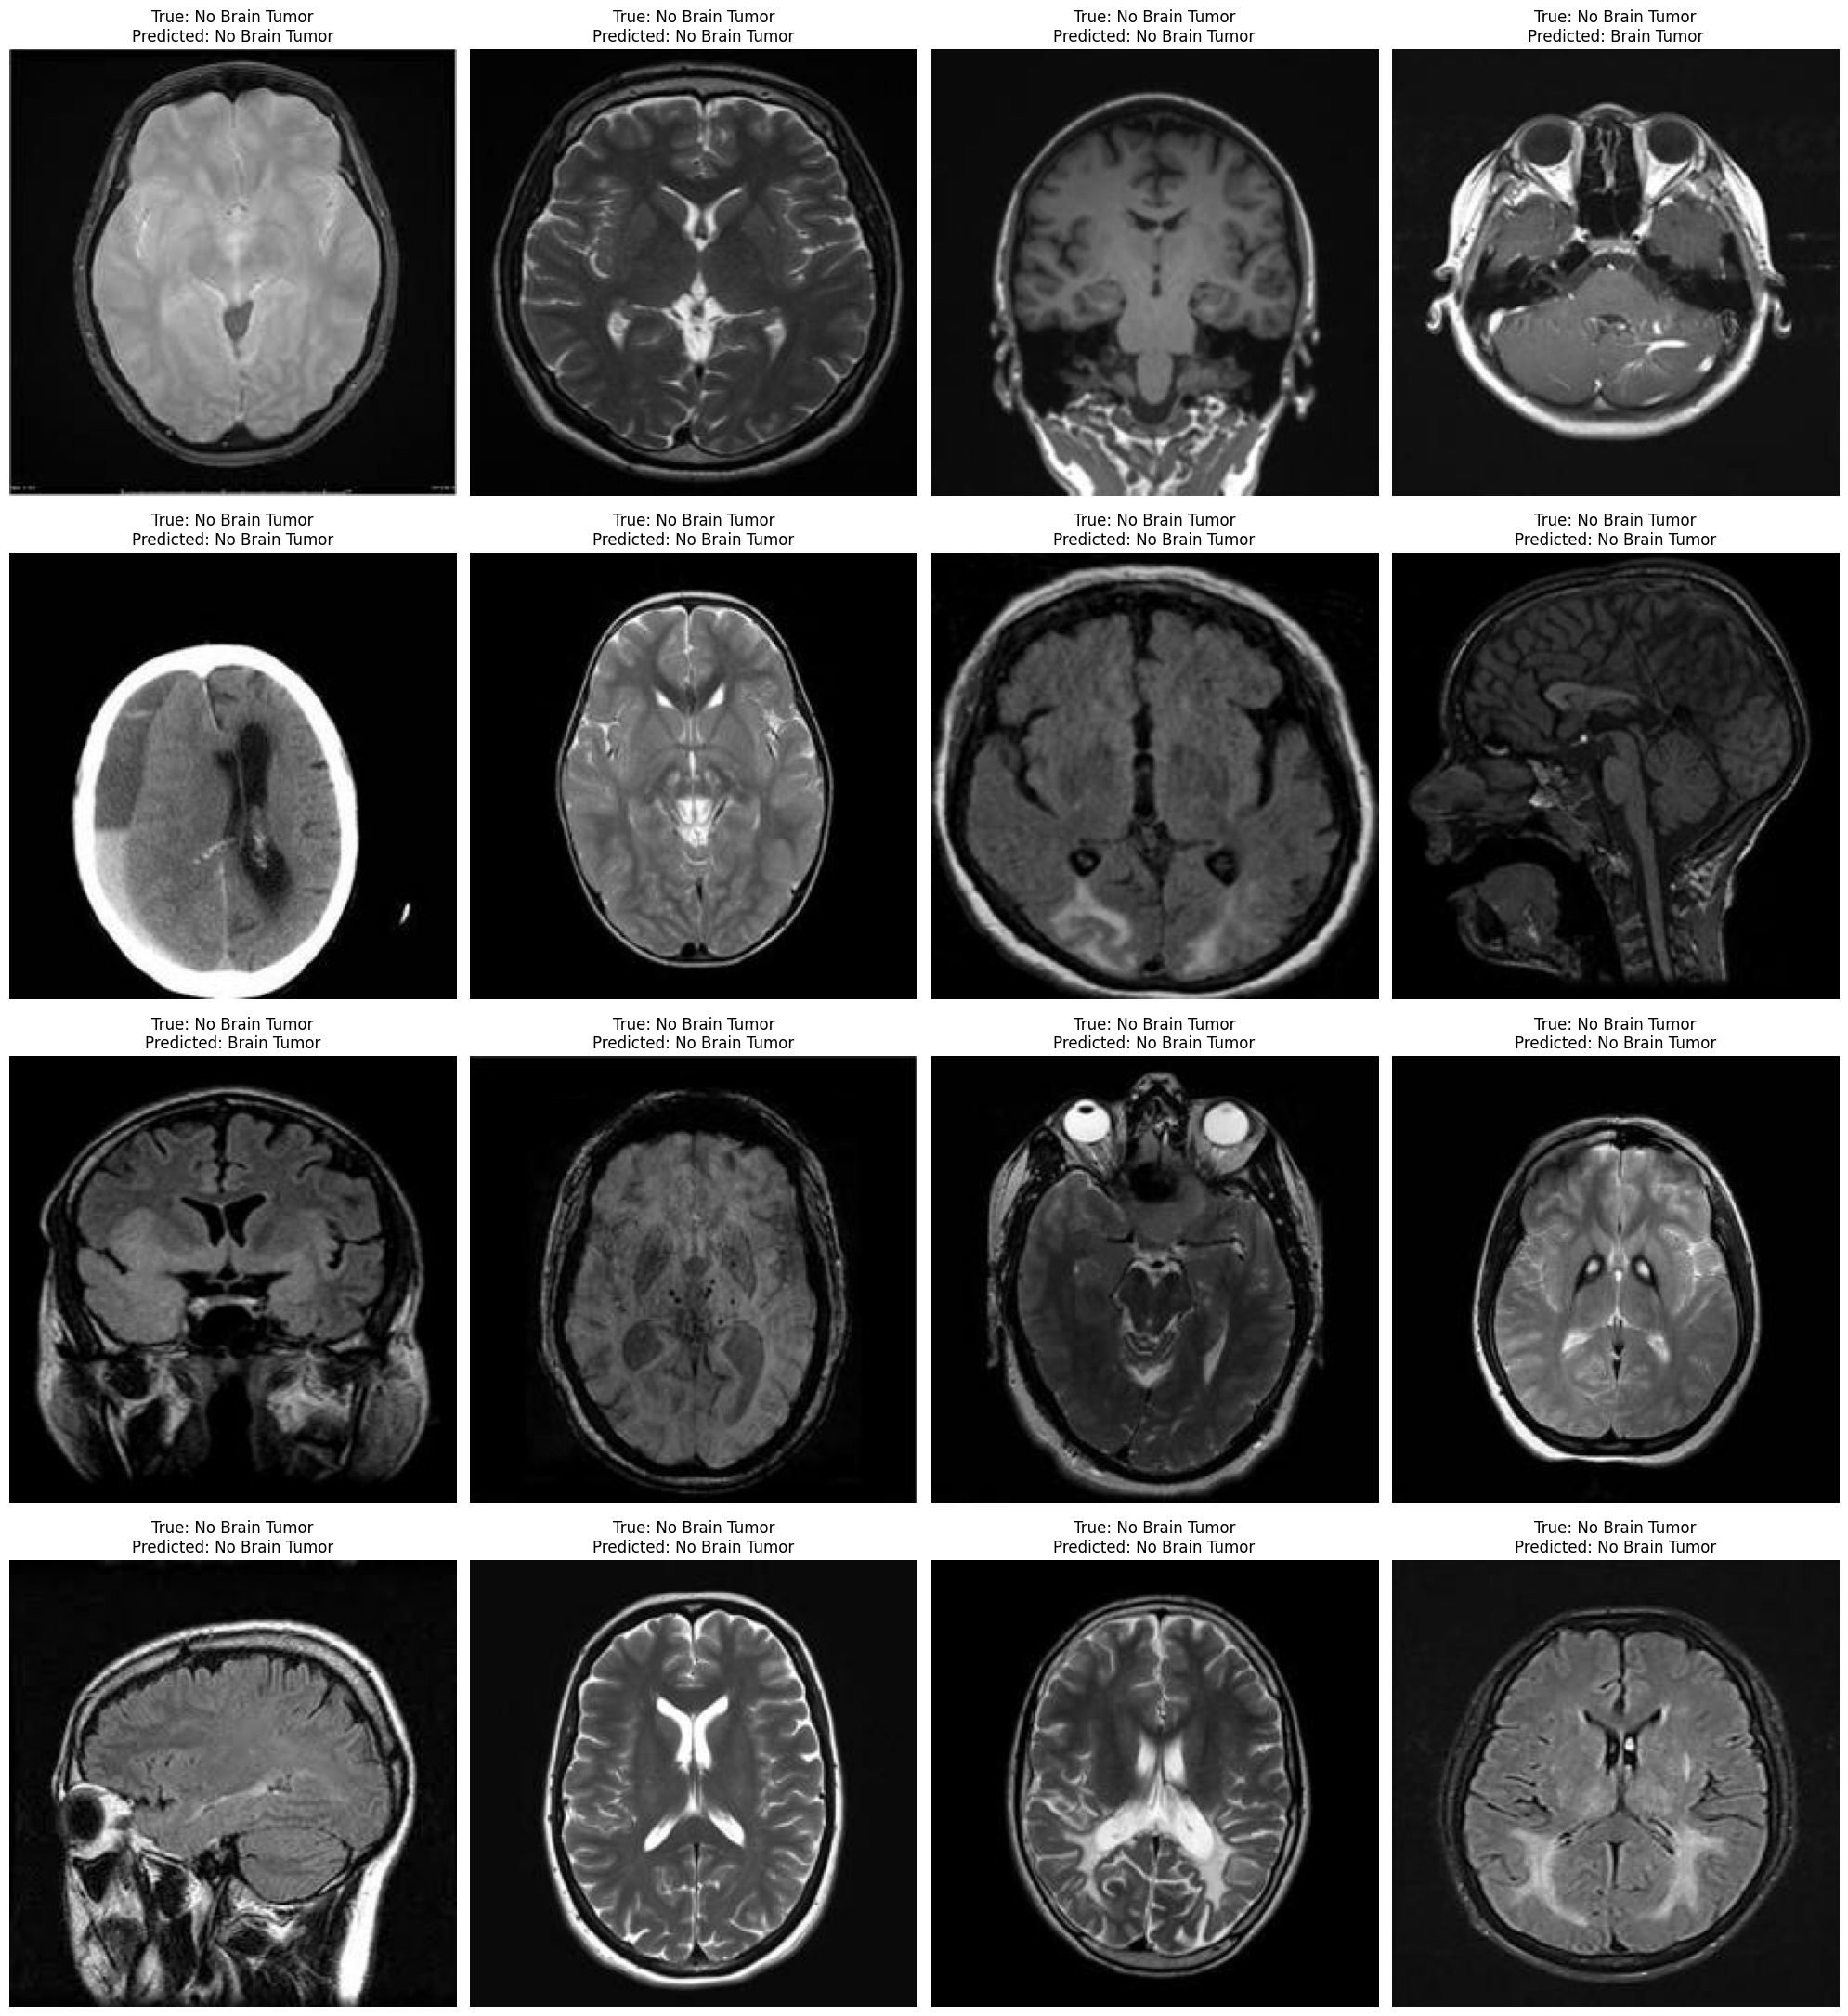

In [93]:
# Interpret and display predictions
class_name = {0: 'No Brain Tumor', 1: 'Brain Tumor'}

fig, axes = plt.subplots(4, 4, figsize=(20, 22))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(test_images[i])
    true_index = np.argmax(test_labels[i])
    predicted_index = np.argmax(predictions[i])
    axes[i].set_title(f'True: {class_name[true_index]}\nPredicted: {class_name[predicted_index]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [92]:
# Make predictions on the test images
predictions = loaded_model.predict(test_images)

print("Predictions made successfully.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predictions made successfully.


In [89]:
import tensorflow as tf

# Load the trained model
# Assuming the model was saved as 'model.keras' during training
loaded_model = tf.keras.models.load_model('model.keras')

print("Trained model loaded successfully.")

Trained model loaded successfully.
